In [2]:
import pandas as pd
import ast
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'gensim'

In [ ]:
df = pd.read_csv("processed_df.csv")

# Convert stringified lists in 'tokens' column back to real lists
df['tokens'] = df['tokens'].apply(ast.literal_eval)

df_subset = df.iloc[:54]
df.info()


<>:1: SyntaxWarning: invalid escape sequence '\A'
<>:1: SyntaxWarning: invalid escape sequence '\A'
C:\Users\pradh\AppData\Local\Temp\ipykernel_21548\1286386053.py:1: SyntaxWarning: invalid escape sequence '\A'
  df = pd.read_csv("E:\Academics\Semester-6\DS 203(Prog. for DS)\Project\Code\processed_df.csv")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 667 entries, 0 to 666
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Session_Summary  667 non-null    object
 1   tokens           667 non-null    object
 2   words_count      667 non-null    int64 
 3   sentence_count   667 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 21.0+ KB


In [ ]:
df.shape

(667, 4)

In [ ]:
tagged_data = [TaggedDocument(words=row, tags=[str(i)]) for i, row in enumerate(df['tokens'])]
tagged_data

In [ ]:

# Define and train Doc2Vec model
model = Doc2Vec(vector_size=300, window=5, min_count=1, workers=4, epochs=3000, dm=1)

model.build_vocab(tagged_data)
model.train(tagged_data, total_examples=model.corpus_count, epochs=model.epochs)

In [ ]:
# Infer vector from tokens of the first doc
tokens = df['tokens'].iloc[200]
inferred_vector = model.infer_vector(tokens)
print(inferred_vector)

[-3.91445279e-01 -1.33562207e+00 -2.47310543e+00  1.89326406e+00
  3.56126761e+00  1.62169111e+00  1.56181002e+00  2.96702528e+00
 -1.81603944e+00  8.76749977e-02  6.50663793e-01  3.43182653e-01
  8.57086539e-01 -1.29252779e+00  1.63143432e+00 -4.65951324e-01
  1.13440044e-01 -2.19560885e+00 -5.44256210e-01  5.37224770e+00
  2.97221631e-01 -2.62503242e+00  1.30235744e+00  1.12591743e+00
  1.59155238e+00 -3.97586703e+00 -1.84279025e+00 -1.48499459e-01
 -4.23239660e+00  1.66547000e+00 -1.22886360e+00  7.77678251e-01
 -1.03227928e-01  2.24486995e+00 -4.39134979e+00  2.17960858e+00
  3.06338048e+00 -9.65824068e-01  1.29184055e+00  3.46416569e+00
  2.49118209e-01 -1.31600070e+00 -1.26409543e+00 -3.39685678e+00
 -2.05781460e-01  2.47336602e+00  1.92082390e-01  2.25663409e-01
  2.28238440e+00 -1.71323383e+00 -2.62231731e+00  7.29015619e-02
 -1.14841485e+00  5.21744847e-01  1.47127426e+00 -1.18141639e+00
 -1.32707834e+00  2.25962090e+00 -5.85291100e+00 -2.55837274e+00
  3.63376546e+00 -1.13706

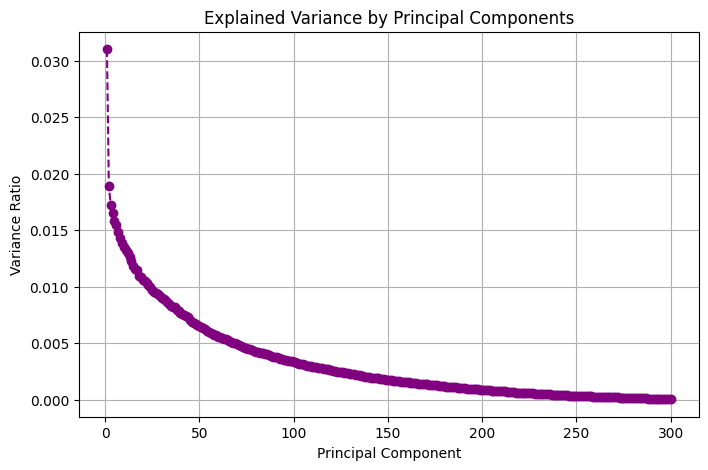

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Get vectors using DataFrame index
doc_vectors = [model.dv[str(i)] for i in df.index]

# Fit PCA
pca = PCA()
pca.fit(doc_vectors)

# Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         pca.explained_variance_ratio_,
         marker='o', linestyle='--', color='purple')

plt.title("Explained Variance by Principal Components")
plt.xlabel("Principal Component")
plt.ylabel("Variance Ratio")
plt.grid(True)
plt.show()


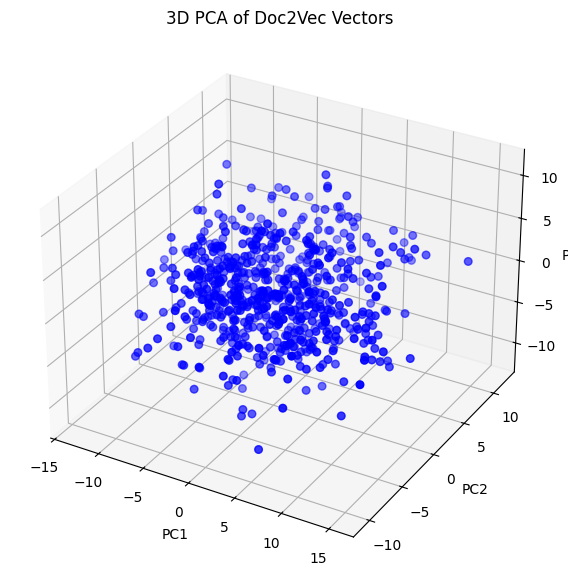

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Get vectors using DataFrame index
doc_vectors = [model.dv[str(i)] for i in df.index]

# PCA for 3D
pca = PCA(n_components=3)
reduced = pca.fit_transform(doc_vectors)

# Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(reduced[:, 0], reduced[:, 1], reduced[:, 2], color='blue', s=30)

ax.set_title("3D PCA of Doc2Vec Vectors")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.show()


In [ ]:
import numpy as np
from scipy.spatial.distance import euclidean

# Infer vector for a document
tokens = df['tokens'].iloc[54]
inferred_vector = model.infer_vector(tokens)

# Compute Euclidean distance to all document vectors
distances = []
for i in range(len(df)):
    vec = model.dv[str(i)]
    dist = euclidean(inferred_vector, vec)
    distances.append((i, dist))

# Get top 5 closest (smallest distance)
closest_docs = sorted(distances, key=lambda x: x[1])[:10]

# Print results
print("Top 5 most similar documents (Euclidean):")
for doc_id, dist in closest_docs:
    print(f"Doc ID: {doc_id}, Distance: {dist:.4f}")
    print("Text:", df.loc[doc_id, 'Session_Summary'])
    print("---")


Top 5 most similar documents (Euclidean):
Doc ID: 54, Distance: 17.1104
Text: levels of measurement : data obtained / represented in different forms should be treated differently instead of blindly feeding it to the computer

our limitation : even after having access to huge data (via internet) we are unable to utilize all of it due to computational constraints, hence we must still take a sample from it

(un)supervised learning : even in the absence of labels ("y"), we can use some techniques to predict the function (y = f(x))
---
Doc ID: 626, Distance: 32.0454
Text: paper discussion of midsem 
---
Doc ID: 407, Distance: 32.7371
Text: we discussed mid sem exam and assignment 3 and later we discussed some problems in data.
---
Doc ID: 599, Distance: 34.6972
Text: evaluated metrics for midsem and exercise.
---
Doc ID: 136, Distance: 35.2315
Text: the instructor conducted a tutorial on how to effectively use pivot tables, providing a detailed explanation of their functionality. additional

In [ ]:
# # Save the model
# model.save("doc2vec_model.model")